# HAT Layer 1 — Prompt Subset Robustness

**Question:** Is the clustering result conditioned on this specific combination
of 40 prompts, or does it hold across random subsets?

**Design:**
- For each subset size x in [22, 24, 26, 28, 30, 32, 34, 36, 38, 40]:
  - Repeat 20 times, each time drawing x/2 neutral and x/2 emotional prompts
    at random from **each run independently**, then concatenating across all 12 runs
    (total trials per repeat = 12 × x)
  - For each repeat: rank features by single-feature accuracy, then run a
    greedy multi-feature sweep, save the best accuracy and ARI found
  - Average accuracy and ARI across the 20 repeats; record std dev
- Plot mean accuracy ± 1 SD vs x (shaded band)

The width of the shaded band answers the question: if it is narrow, the result
is robust to which prompts are selected; if it is wide, the signal is
sensitive to the specific prompt subset.


## §1 — Imports

In [26]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score, confusion_matrix

warnings.filterwarnings('ignore')
plt.rcParams['figure.dpi'] = 120
print('Imports OK')


Imports OK


## §2 — Configuration

In [27]:
x=7
if x ==7:
    BASE_DIR = Path.home() / 'Desktop' / 'mccviahat'
    DATA_DIR = BASE_DIR / 'data' / 'clemsonc6420'
    RUNS = ['A', 'B', 'D', 'E', 'F', 'AA', 'AB', 'AC', '1', '2', '3', '4']
else:
    BASE_DIR   = Path.home() / 'Desktop' / 'mccviahat'
    DATA_DIR   = BASE_DIR / 'data' / '70b'
    RUNS = ['1', '2', '3','4','5','6', '7']


assert BASE_DIR.exists(), f'Repo root not found: {BASE_DIR}'

# ── Runs to load ──────────────────────────────────────────────────────────────
# Add or remove run labels here as new data arrives
    # Subset sizes (must be even — x/2 per class per run)
SUBSET_SIZES = [22, 24, 26, 28, 30, 32, 34, 36, 38, 40]

# Number of random repeats per subset size
N_REPEATS = 20

# KMeans settings
N_INIT    = 50
RAND_SEED = 42

# Max features in the multi-feature sweep
MAX_N_FEATURES = 15





L1_INDICATORS = [
    'hat_TLB',
    'tlb:tlb_flush',
    'core_power.throttle',
]

EXCLUDE_INDICATORS = {
    'hat_NMI', 'hat_PMI', 'hat_LOC', 'hat_RES', 'hat_CAL', 'hat_MCP',
    'hat_BLOCK', 'hat_IWI', 'hat_NET_RX', 'hat_NET_TX',
    'hat_RCU', 'hat_SCHED', 'hat_TASKLET', 'hat_TIMER',
    'irq:irq_handler_entry', 'irq:irq_handler_exit',
    'irq:softirq_entry', 'irq:softirq_exit', 'irq:softirq_raise',
}

print('Configuration OK')
print(f'  Runs         : {RUNS}')
print(f'  Subset sizes : {SUBSET_SIZES}')
print(f'  Repeats      : {N_REPEATS}')
print(f'  Total trials per repeat: {[12*x for x in SUBSET_SIZES]}')


Configuration OK
  Runs         : ['A', 'B', 'D', 'E', 'F', 'AA', 'AB', 'AC', '1', '2', '3', '4']
  Subset sizes : [22, 24, 26, 28, 30, 32, 34, 36, 38, 40]
  Repeats      : 20
  Total trials per repeat: [264, 288, 312, 336, 360, 384, 408, 432, 456, 480]


## §3 — Load data

In [28]:
dfs = {}
loaded, missing = [], []

for run in RUNS:
    p = DATA_DIR / f'independent{run}.csv'
    if p.exists():
        df = pd.read_csv(p)
        df['run'] = run
        dfs[run] = df
        loaded.append(run)
    else:
        missing.append(run)

if missing:
    print(f'⚠  Not found: {missing}')

df_all = pd.concat(dfs.values(), ignore_index=True)

print(f'Loaded {len(loaded)} runs: {loaded}')
print(f'  Total trials : {len(df_all)}')
print(f'  Neutral      : {(df_all.condition == "neutral").sum()}')
print(f'  Emotional    : {(df_all.condition == "emotional").sum()}')
print(f'  Per-run      : {df_all.groupby("run").size().to_dict()}')


Loaded 12 runs: ['A', 'B', 'D', 'E', 'F', 'AA', 'AB', 'AC', '1', '2', '3', '4']
  Total trials : 480
  Neutral      : 240
  Emotional    : 240
  Per-run      : {'1': 40, '2': 40, '3': 40, '4': 40, 'A': 40, 'AA': 40, 'AB': 40, 'AC': 40, 'B': 40, 'D': 40, 'E': 40, 'F': 40}


## §4 — Identify L1 feature columns

In [29]:
def indicator_of(col):
    for ind in L1_INDICATORS:
        if col.startswith(ind + '__'):
            return ind
    return ''

all_feat_cols = [c for c in df_all.columns if '__' in c]

# Drop all-zero indicators
zero_rate_inds = set()
for ind in L1_INDICATORS:
    mc = f'{ind}__mean_rate'
    if mc in df_all.columns:
        vals = pd.to_numeric(df_all[mc], errors='coerce').fillna(0)
        if (vals.abs() < 1e-9).all():
            zero_rate_inds.add(ind)

l1_cols = [
    c for c in all_feat_cols
    if indicator_of(c) in L1_INDICATORS
    and indicator_of(c) not in zero_rate_inds
    and indicator_of(c) not in EXCLUDE_INDICATORS
]

# Drop all-NaN and zero-variance columns on the full dataset
X_check = df_all[l1_cols].apply(pd.to_numeric, errors='coerce')
l1_cols = [c for c in l1_cols
           if X_check[c].notna().any() and X_check[c].std() > 0]

print(f'Active L1 indicators : {[i for i in L1_INDICATORS if i not in zero_rate_inds]}')
print(f'Excluded (all-zero)  : {sorted(zero_rate_inds)}')
print(f'L1 feature columns   : {len(l1_cols)}')


Active L1 indicators : ['hat_TLB', 'tlb:tlb_flush', 'core_power.throttle']
Excluded (all-zero)  : []
L1 feature columns   : 30


## §5 — Clustering helpers

In [30]:
def kmeans_acc_ari(X: np.ndarray, y: np.ndarray,
                   n_init: int = N_INIT, seed: int = RAND_SEED):
    """Standardise, fit KMeans k=2, majority-vote align, return (acc, ari)."""
    Xs = StandardScaler().fit_transform(X)
    km = KMeans(n_clusters=2, n_init=n_init, random_state=seed).fit(Xs)
    pred = km.labels_
    cm = confusion_matrix(y, pred)
    if cm.shape != (2, 2):
        return 0.5, 0.0
    acc = max((cm[0,0]+cm[1,1])/cm.sum(), (cm[0,1]+cm[1,0])/cm.sum())
    ari = adjusted_rand_score(y, pred)
    return float(acc), float(ari)


def best_config_on_subset(sub_df, cols, max_n=MAX_N_FEATURES,
                           n_init=N_INIT, seed=RAND_SEED):
    """
    Given a subset dataframe:
    1. Rank all L1 feature columns by single-feature accuracy.
    2. Greedy multi-feature sweep: add the next-best feature at each step.
    3. Return (best_acc, best_ari, best_n) across the sweep.
    """
    y = (sub_df['condition'] == 'emotional').astype(int).values

    X_raw = sub_df[cols].apply(pd.to_numeric, errors='coerce')
    X_raw = X_raw.fillna(X_raw.median())

    # Drop zero-variance columns in this subset
    valid_cols = [c for c in cols if X_raw[c].std() > 0]
    if not valid_cols:
        return 0.5, 0.0, 0

    # Step 1: single-feature ranking
    sf = []
    for c in valid_cols:
        acc, ari = kmeans_acc_ari(X_raw[[c]].values, y, n_init=n_init, seed=seed)
        sf.append((c, acc, ari))
    sf.sort(key=lambda r: r[1], reverse=True)
    ranked = [r[0] for r in sf]

    # Step 2: greedy multi-feature sweep
    best_acc, best_ari, best_n = 0.0, 0.0, 0
    for n in range(1, min(max_n, len(ranked)) + 1):
        acc, ari = kmeans_acc_ari(X_raw[ranked[:n]].values, y,
                                  n_init=n_init, seed=seed)
        if acc > best_acc:
            best_acc, best_ari, best_n = acc, ari, n

    return best_acc, best_ari, best_n


print('Helpers defined.')


Helpers defined.


## §6 — Robustness sweep

For each subset size x, repeat N_REPEATS times:
- Draw x/2 neutral and x/2 emotional rows at random from each run
- Concatenate across all 12 runs (total = 12 × x trials)
- Run single-feature ranking + greedy multi-feature sweep
- Save best accuracy and ARI for this repeat

Then average across repeats and record mean ± std.


In [31]:
rng = np.random.default_rng(RAND_SEED)

results = []

for x in SUBSET_SIZES:
    n_per_class = x // 2
    rep_accs, rep_aris = [], []

    for rep in range(N_REPEATS):
        sub_parts = []
        for run in loaded:
            df_run = dfs[run]
            neut = df_run[df_run.condition == 'neutral']
            emot = df_run[df_run.condition == 'emotional']

            if len(neut) < n_per_class or len(emot) < n_per_class:
                continue  # skip run if not enough trials

            idx_n = rng.choice(len(neut), size=n_per_class, replace=False)
            idx_e = rng.choice(len(emot), size=n_per_class, replace=False)

            sub_parts.append(neut.iloc[idx_n])
            sub_parts.append(emot.iloc[idx_e])

        if not sub_parts:
            continue

        sub = pd.concat(sub_parts, ignore_index=True)
        acc, ari, best_n = best_config_on_subset(sub, l1_cols)
        rep_accs.append(acc)
        rep_aris.append(ari)

    mean_acc = np.mean(rep_accs)
    std_acc  = np.std(rep_accs)
    mean_ari = np.mean(rep_aris)
    std_ari  = np.std(rep_aris)

    results.append({
        'x':        x,
        'total':    12 * x,
        'mean_acc': mean_acc,
        'std_acc':  std_acc,
        'mean_ari': mean_ari,
        'std_ari':  std_ari,
    })

    print(f'x={x:2d}  ({12*x} trials)  '
          f'acc={mean_acc:.4f} ± {std_acc:.4f}  '
          f'ARI={mean_ari:.4f} ± {std_ari:.4f}')

res = pd.DataFrame(results)


x=22  (264 trials)  acc=0.5616 ± 0.0111  ARI=0.0121 ± 0.0054
x=24  (288 trials)  acc=0.5609 ± 0.0103  ARI=0.0120 ± 0.0052
x=26  (312 trials)  acc=0.5643 ± 0.0111  ARI=0.0139 ± 0.0059
x=28  (336 trials)  acc=0.5558 ± 0.0113  ARI=0.0101 ± 0.0052
x=30  (360 trials)  acc=0.5572 ± 0.0083  ARI=0.0107 ± 0.0037
x=32  (384 trials)  acc=0.5536 ± 0.0097  ARI=0.0094 ± 0.0046
x=34  (408 trials)  acc=0.5515 ± 0.0073  ARI=0.0084 ± 0.0031
x=36  (432 trials)  acc=0.5506 ± 0.0065  ARI=0.0081 ± 0.0027
x=38  (456 trials)  acc=0.5482 ± 0.0052  ARI=0.0073 ± 0.0021
x=40  (480 trials)  acc=0.5444 ± 0.0010  ARI=0.0059 ± 0.0004


## §7 — Plot

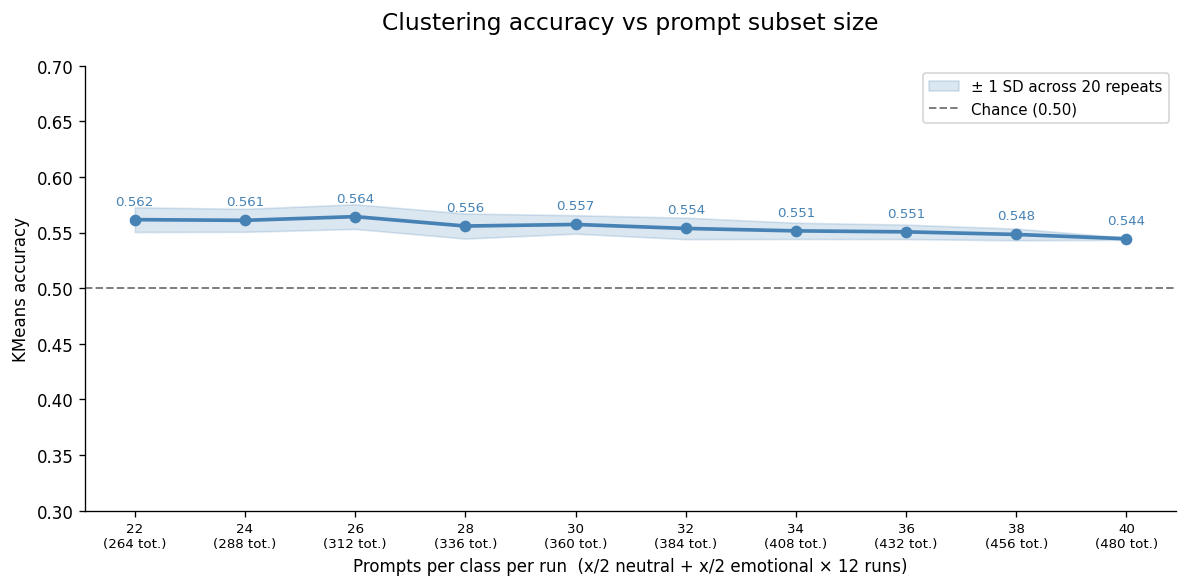

Saved: l1_robustness.png


In [40]:
fig, ax = plt.subplots(figsize=(10, 5))

xs   = res['x'].values
mean = res['mean_acc'].values
std  = res['std_acc'].values

ax.plot(xs, mean, marker='o', lw=2.2, color='steelblue', zorder=3)
ax.fill_between(xs, mean - std, mean + std,
                alpha=0.20, color='steelblue', label='± 1 SD across 20 repeats')

for xi, mi in zip(xs, mean):
    ax.annotate(f'{mi:.3f}', (xi, mi),
                textcoords='offset points', xytext=(0, 9),
                ha='center', fontsize=8, color='steelblue')

ax.axhline(0.5, color='grey', lw=1.2, ls='--', label='Chance (0.50)')

ax.set_xlabel('Prompts per class per run  (x/2 neutral + x/2 emotional × 12 runs)',
              fontsize=10)
ax.set_ylabel('KMeans accuracy', fontsize=10)
ax.set_title(
    f'Clustering accuracy vs prompt subset size\n',
   fontsize=14)
ax.set_xticks(xs)
ax.set_xticklabels([f'{xi}\n({12*xi} tot.)' for xi in xs], fontsize=8)
ax.set_ylim(0.3, 0.7)
ax.legend(fontsize=9)
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig('l1_robustness.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: l1_robustness.png')

## §8 — Summary table

In [33]:
print('Robustness sweep — Layer 1 clustering')
print('=' * 72)
print(f'  {"x":>4}  {"total":>6}  {"mean acc":>9}  {"± SD":>7}  '
      f'{"mean ARI":>9}  {"± SD":>7}')
print('-' * 72)
for _, r in res.iterrows():
    print(f'  {int(r.x):>4}  {int(r.total):>6}  {r.mean_acc:>9.4f}  '
          f'{r.std_acc:>7.4f}  {r.mean_ari:>9.4f}  {r.std_ari:>7.4f}')
print()
print(f'Chance baseline: acc = 0.5000,  ARI = 0.0000')
print()

# Interpretation
max_std = res['std_acc'].max()
min_std = res['std_acc'].min()
mean_mean = res['mean_acc'].mean()
print(f'Mean accuracy across all subset sizes: {mean_mean:.4f}')
print(f'SD range: {min_std:.4f} – {max_std:.4f}')
if max_std < 0.04:
    print('→  Narrow band: result is stable across random prompt selections.')
elif max_std < 0.07:
    print('→  Moderate band: some sensitivity to prompt selection.')
else:
    print('→  Wide band: result is sensitive to which prompts are selected.')


Robustness sweep — Layer 1 clustering
     x   total   mean acc     ± SD   mean ARI     ± SD
------------------------------------------------------------------------
    22     264     0.5616   0.0111     0.0121   0.0054
    24     288     0.5609   0.0103     0.0120   0.0052
    26     312     0.5643   0.0111     0.0139   0.0059
    28     336     0.5558   0.0113     0.0101   0.0052
    30     360     0.5572   0.0083     0.0107   0.0037
    32     384     0.5536   0.0097     0.0094   0.0046
    34     408     0.5515   0.0073     0.0084   0.0031
    36     432     0.5506   0.0065     0.0081   0.0027
    38     456     0.5482   0.0052     0.0073   0.0021
    40     480     0.5444   0.0010     0.0059   0.0004

Chance baseline: acc = 0.5000,  ARI = 0.0000

Mean accuracy across all subset sizes: 0.5548
SD range: 0.0010 – 0.0113
→  Narrow band: result is stable across random prompt selections.
